##**Import the dependancies**

In [1]:
import os
import time
import json
import re
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from wordcloud import WordCloud

from zipfile import ZipFile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix , classification_report

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input , Dense , Embedding , LSTM , GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


###**Global Variables**

In [2]:
MAX_LENGTH = 200
TEST_SIZE = 0.2
RANDOM_STATE = 42
BATCH_SIZE = 64
EPOCHS = 10
VOCAB_SIZE = 5000
EMBEDDING_DIM = 128
VAL_SIZE=0.2
STOP_WORDS = set(stopwords.words('english'))

##**Loading the data using Kaggle API**

In [3]:
kaggle_dict = json.load(open('kaggle.json'))
kaggle_dict.keys()

dict_keys(['username', 'key'])

In [4]:
os.environ['KAGGLE_USERNAME'] = kaggle_dict['username']
os.environ['KAGGLE_KEY'] = kaggle_dict['key']

In [5]:
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:00<00:00, 69.5MB/s]



In [6]:
!ls


imdb-dataset-of-50k-movie-reviews.zip  kaggle.json  sample_data


In [7]:
# unzip the file
with ZipFile('imdb-dataset-of-50k-movie-reviews.zip','r') as zip_ref:
  zip_ref.extractall()

In [8]:
!ls

'IMDB Dataset.csv'			 kaggle.json
 imdb-dataset-of-50k-movie-reviews.zip	 sample_data


##**Loading the data**

In [9]:
df = pd.read_csv('IMDB Dataset.csv')

In [10]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [11]:
df.shape

(50000, 2)

In [12]:
df['sentiment'].value_counts()
# the data is perfectly balanced

,count
sentiment,
positive,25000
negative,25000


In [13]:
df.isnull().sum()

,0
review,0
sentiment,0


##**EDA**

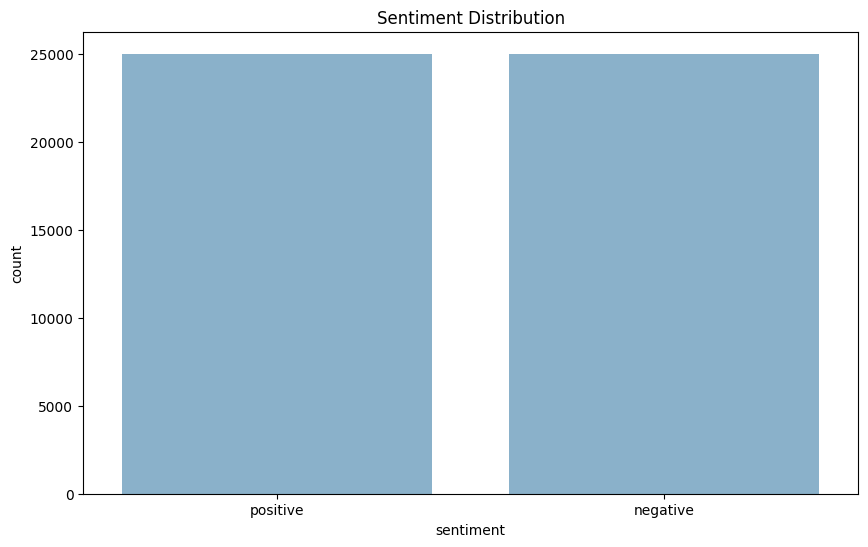

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(x=df['sentiment'],color='#7FB3D5')
plt.title('Sentiment Distribution')
plt.show()

In [15]:
# get the review length
df['review-length'] = df['review'].apply(lambda x: len(x.split()))

In [16]:
df.head()

,review,sentiment,review-length
0,One of the other reviewers has mentioned that ...,positive,307
1,A wonderful little production. <br /><br />The...,positive,162
2,I thought this was a wonderful way to spend ti...,positive,166
3,Basically there's a family where a little boy ...,negative,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230


In [17]:
df['review-length'].describe()

,review-length
count,50000.000000
mean,231.156940
std,171.343997
min,4.000000
25%,126.000000
50%,173.000000
75%,280.000000
max,2470.000000


In [18]:
#  positive review's word length <= 200 is 59.1 %
positive_reviews = df[df['sentiment'] == 'positive']
pos_percentage_less_max = positive_reviews[positive_reviews['review-length'] <= MAX_LENGTH].shape[0] / positive_reviews.shape[0] * 100
print(pos_percentage_less_max)

59.156


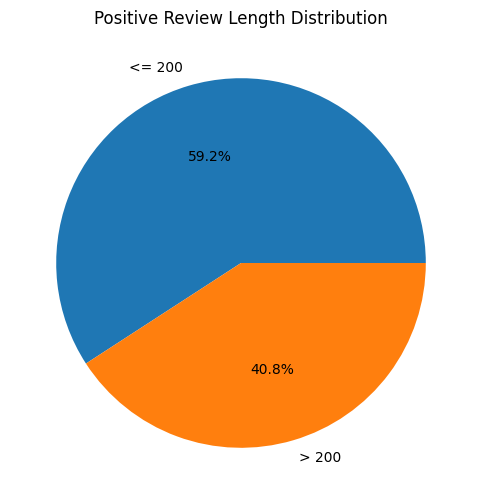

In [19]:
sizes = [
    (positive_reviews['review-length'] <= MAX_LENGTH).sum(),
    (positive_reviews['review-length'] > MAX_LENGTH).sum()
]

labels = [
    f'<= {MAX_LENGTH}',
    f'> {MAX_LENGTH}'
]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
)

plt.title('Positive Review Length Distribution')
plt.show()

In [20]:
#  negative review's word length <= 200 is 59.1 %
negative_reviews = df[df['sentiment'] == 'negative']
neg_percentage_less_max = negative_reviews[negative_reviews['review-length'] <= MAX_LENGTH].shape[0] / negative_reviews.shape[0] * 100
print(neg_percentage_less_max)

59.123999999999995


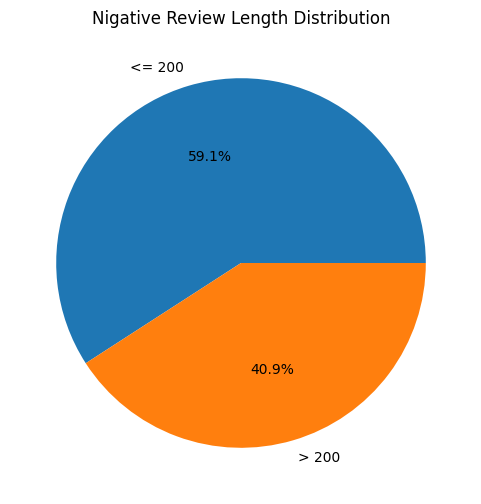

In [21]:
sizes = [
    (negative_reviews['review-length'] <= MAX_LENGTH).sum(),
    (negative_reviews['review-length'] > MAX_LENGTH).sum()
]

labels = [
    f'<= {MAX_LENGTH}',
    f'> {MAX_LENGTH}'
]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
)

plt.title('Nigative Review Length Distribution')
plt.show()

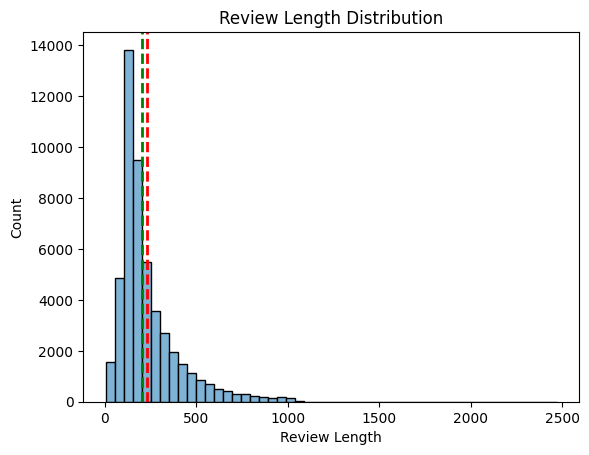

In [22]:
# total reviews distribution

plt.hist(df['review-length'],edgecolor='black',bins=50,color='#7FB3D5')
plt.axvline(df['review-length'].mean(),color='red',linestyle='--',linewidth=2)
plt.axvline(MAX_LENGTH,color='green',linestyle='--',linewidth=2)
plt.xlabel('Review Length')
plt.ylabel('Count')
plt.title('Review Length Distribution')
plt.show()

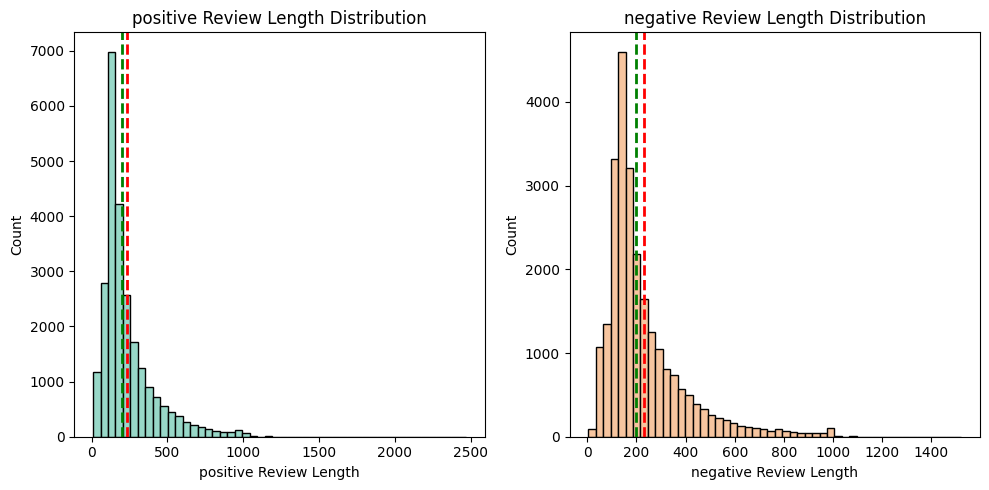

In [23]:
fig , ax = plt.subplots(1,2,figsize=(10,5))
colors = ['#98D8C8','#F7C59F']
for i , sentiment in enumerate(['positive','negative']):
  reviews = df[df['sentiment'] == sentiment]
  # Positive reviews distribution
  ax[i].hist(
      reviews['review-length'],
      bins=50,
      edgecolor='black',
      color=colors[i]
      )
  ax[i].axvline(reviews['review-length'].mean(),color='red',linestyle='--',linewidth=2)
  ax[i].axvline(MAX_LENGTH,color='green',linestyle='--',linewidth=2)
  ax[i].set_xlabel(f'{sentiment} Review Length')
  ax[i].set_ylabel('Count')
  ax[i].set_title(f'{sentiment} Review Length Distribution')
plt.tight_layout()
plt.show()

##**Text Preprocessing**

###Text cleaning

In [24]:
STOP_WORDS_PATTERN = re.compile(
    r'\b(' + '|'.join(STOP_WORDS) + r')\b\s*'
)

def clean_text(text):
  # remove HTML
  text = re.sub(r'<[^>]+>',' ',text)

  # remove url
  text = re.sub(r'http\S+','',text)


  # remove email adress
  text = re.sub(r'\S+@\S+','',text)

  # remove special characters
  text = re.sub(r'[^a-zA-Z0-9\s]','',text)

  # remove numbers
  text = re.sub(r'\d+','',text)

  # convert text to lowercase
  text = text.lower()

  # remove extra spaces
  text = re.sub(r'\s+',' ',text)

  # remove punctuation
  text = text.translate(str.maketrans('', '', string.punctuation))

  # remove stopwords
  text = STOP_WORDS_PATTERN.sub('', text)

  return text

In [25]:
# showing example of text cleaning before and after
print('='*10,'Before Cleaning','='*10)
print(df['review'][0])
print('='*10,'After Cleaning','='*10)
print(clean_text(df['review'][0]))

========== Before Cleaning ==========
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the mai

In [26]:
# apply cleaning on all text
df['cleaned_review'] = df['review'].apply(clean_text)

In [27]:
df.head()

,review,sentiment,review-length,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,307,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,162,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,166,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,138,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,petter matteis love time money visually stunni...


###Word Cloud

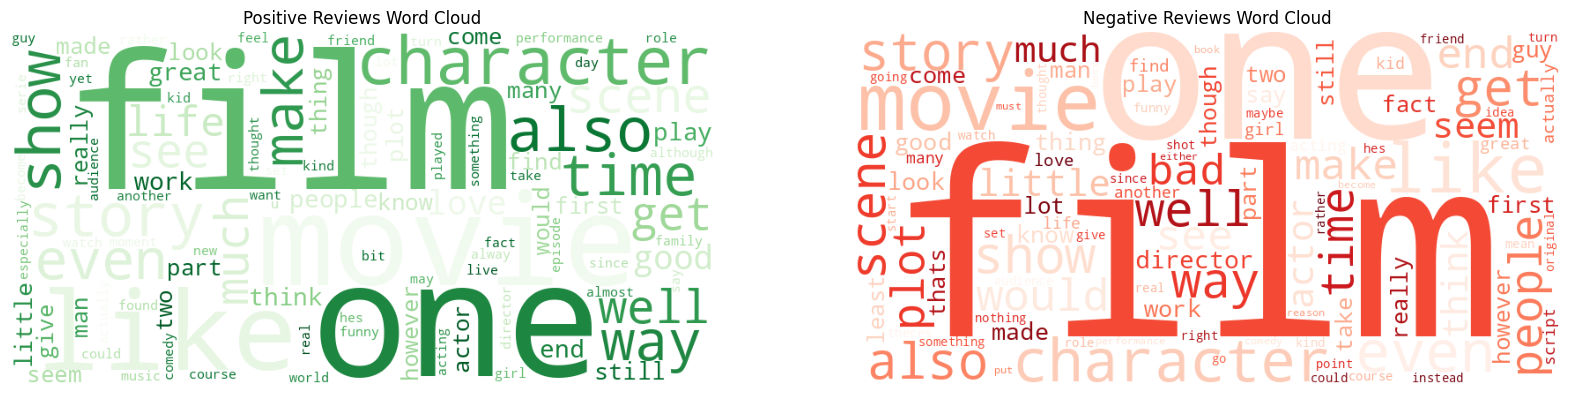

In [28]:
cleaned_positive = ' '.join(df[df['sentiment'] == 'positive']['cleaned_review'])
cleaned_negative = ' '.join(df[df['sentiment'] == 'negative']['cleaned_review'])

WC_positive = WordCloud(background_color='white',width=800,height=400,colormap='Greens',stopwords=STOP_WORDS,max_words=100).generate(cleaned_positive)
WC_negative = WordCloud(background_color='white',width=800,height=400,colormap='Reds',stopwords=STOP_WORDS,max_words=100).generate(cleaned_negative)

fig , ax = plt.subplots(1,2,figsize=(20,10))
ax[0].imshow(WC_positive)
ax[0].axis('off')
ax[0].set_title('Positive Reviews Word Cloud')

ax[1].imshow(WC_negative)
ax[1].axis('off')
ax[1].set_title('Negative Reviews Word Cloud')

plt.show()

###label the sentiment to prepare it to model
* Positive -> 1
* Negative -> 0

In [29]:
df['sentiment'] = df['sentiment'].map({'positive':1,'negative':0})

In [30]:
df['sentiment'].value_counts()

,count
sentiment,
1,25000
0,25000


###Splitting the data

In [31]:
X = df['cleaned_review']
Y = df['sentiment']

In [32]:
x_train, x_test , y_train  , y_test = train_test_split(X,Y,test_size=TEST_SIZE,random_state=RANDOM_STATE , stratify=Y)

In [33]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(40000,)
(10000,)
(40000,)
(10000,)


In [34]:
x_train = x_train.astype(str)
x_test = x_test.astype(str)

###Tokenize the train data

In [35]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE)
tokenizer.fit_on_texts(x_train)
x_train = pad_sequences(tokenizer.texts_to_sequences(x_train),maxlen=MAX_LENGTH)
x_test = pad_sequences(tokenizer.texts_to_sequences(x_test),maxlen=MAX_LENGTH)

In [36]:
x_train.shape

(40000, 200)

In [37]:
x_test.shape


(10000, 200)

##**Build The Model ( LSTM Vs GRU )**

####**Models Architecture**
1. Embedding layer :- to convert every integer sequence into vector represintation to add a meaning to words.

2. LSTM layer :- a recurrent layer to proccess the sequence and learn the patteren.

3. dense layer :- it is a traditional Neural Network to represent the output

##LSTM

In [38]:
# build the model

LSTM_model = Sequential()
LSTM_model.add(Input(shape=(MAX_LENGTH,)))
LSTM_model.add(Embedding(VOCAB_SIZE,EMBEDDING_DIM))
LSTM_model.add(LSTM(128,dropout=0.2,recurrent_dropout=0.2))
LSTM_model.add(Dense(1,activation='sigmoid'))

In [39]:
LSTM_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771,713 (2.94 MB)

 Trainable params: 771,713 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# compile the model

LSTM_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
# training the model
start_time = time.time()

LSTM_model_training = LSTM_model.fit(x_train,y_train,
                       batch_size = BATCH_SIZE,
                       epochs = EPOCHS,
                       validation_split=VAL_SIZE,
                       callbacks = EarlyStopping(monitor='val_accuracy',patience=3,restore_best_weights=True)
                       )

end_time = time.time()
total_LSTM_time = end_time - start_time

Epoch 1/10
 61/500 ━━━━━━━━━━━━━━━━━━━━ 2:51 391ms/step - accuracy: 0.5695 - loss: 0.6813

###**LSTM Model Evaluation**

In [ ]:
loss , accuracy = LSTM_model.evaluate(x_test,y_test)
print("Loss: ",loss)
print("Accuracy: ",accuracy)

In [ ]:
total_LSTM_time = np.round(total_LSTM_time / 60,1)
print(f'LSTM training time : {total_LSTM_time} MIN' )

In [ ]:
LSTM_model.save('LSTM_model.keras')

###Confusion matrix & classification report



In [ ]:
LSTM_prediction = LSTM_model.predict(x_test)
LSTM_prediction = (LSTM_prediction > 0.5).astype(int)
LSTM_prediction = LSTM_prediction.flatten()
CM = confusion_matrix(y_test,LSTM_prediction)
print(CM)

In [ ]:
cls = classification_report(y_test,LSTM_prediction)
print(cls)

###Plotting the model loss & accuracy

In [ ]:
fig , ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(LSTM_model_training.history['loss'],label='Training Loss')
ax[0].plot(LSTM_model_training.history['val_loss'],label='Validation Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('LSTM Model Loss')
ax[0].legend()

ax[1].plot(LSTM_model_training.history['accuracy'],label='Training accuracy')
ax[1].plot(LSTM_model_training.history['val_accuracy'],label='Validation accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('accuracy')
ax[1].set_title('LSTM Model accuracy')
ax[1].legend()
plt.show()

###**LSTM Report**

In [ ]:
print('='*40,'LSTM Report','='*40)
print('\n')
print(f'LSTM Total Params is : {LSTM_model.count_params()} parameters')
print(f'total LSTM training time is : {total_LSTM_time / 60 :0.1f} Min')
print(f'LSTM loss : {loss : 0.3f}')
print(f'LSTM accuracy : {accuracy : 0.3f}')
print('\n')
print('='*20,'LSTM Confusion Matrix','='*20)
print('\n')
print(CM)
print('\n')
print('='*20,'LSTM Classification Report','='*20)
print('\n')
print(cls)

###**GRU Model**

In [ ]:
# build the model

GRU_model = Sequential()
GRU_model.add(Input(shape=(MAX_LENGTH,)))
GRU_model.add(Embedding(VOCAB_SIZE,EMBEDDING_DIM))
GRU_model.add(GRU(128,dropout=0.2,recurrent_dropout=0.2))
GRU_model.add(Dense(1,activation='sigmoid'))

In [ ]:
GRU_model.summary()

In [ ]:
# compile the model

GRU_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
# training the model
start_time = time.time()

GRU_model_training = GRU_model.fit(x_train,y_train,
                       batch_size = BATCH_SIZE,
                       epochs = EPOCHS,
                       validation_split=VAL_SIZE,
                       callbacks = EarlyStopping(monitor='val_accuracy',patience=3,restore_best_weights=True)
                       )

end_time = time.time()
total_GRU_time = end_time - start_time

In [ ]:
total_GRU_time = np.round(total_GRU_time / 60,1)

###**GRU Model Evaluation**

In [ ]:
GRU_loss , GRU_accuracy = GRU_model.evaluate(x_test,y_test)
print("Loss: ",GRU_loss)
print("Accuracy: ",GRU_accuracy)

In [ ]:
print(f'GRU training time : {total_GRU_time} MIN' )

###Confusion matrix & classification report


In [ ]:
GRU_prediction = GRU_model.predict(x_test)
GRU_prediction = (GRU_prediction > 0.5).astype(int)
GRU_prediction = GRU_prediction.flatten()
GRU_CM = confusion_matrix(y_test,GRU_prediction)
print(GRU_CM)

In [ ]:
GRU_cls = classification_report(y_test,GRU_prediction,output_dict=True)
print(GRU_cls)

###Plotting model accuracy & loss

In [ ]:
fig , ax = plt.subplots(1,2,figsize=(15,5))
ax[0].plot(GRU_model_training.history['loss'],label='Training Loss')
ax[0].plot(GRU_model_training.history['val_loss'],label='Validation Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('GRU Model Loss')
ax[0].legend()

ax[1].plot(GRU_model_training.history['accuracy'],label='Training accuracy')
ax[1].plot(GRU_model_training.history['val_accuracy'],label='Validation accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('accuracy')
ax[1].set_title('GRU Model accuracy')
ax[1].legend()
plt.show()

###**GRU Report**

In [ ]:
print('='*40,'GRU Report','='*40)
print('\n')
print(f'GRU Total Params is : {GRU_model.count_params()} parameters')
print(f'total GRU training time is : {total_GRU_time} Min')
print(f'GRU loss : {GRU_loss : 0.3f}')
print(f'GRU accuracy : {GRU_accuracy : 0.3f}')
print('\n')
print('='*20,'GRU Confusion Matrix','='*20)
print('\n')
print(GRU_CM)
print('\n')
print('='*20,'GRU Classification Report','='*20)
print('\n')
print(GRU_cls)

#**Full Report ( LSTM Vs GRU )**

In [ ]:
cls = classification_report(y_test,LSTM_prediction,output_dict=True)
GRU_cls = classification_report(y_test,GRU_prediction,output_dict=True)

In [ ]:
print('='*60)
print(f'{'Model':<20}{'LSTM':<20}{'GRU':<20}')
print('='*60)
print(f'{"Total Params":<20}{LSTM_model.count_params():<20}{GRU_model.count_params():<20}\n')
print(f'{"Total Time":<20}{total_LSTM_time:<20}{total_GRU_time:<20}\n')
print(f'{"Precision":<20}{cls['weighted avg']['precision']:<20.2f}{GRU_cls['weighted avg']['precision']:<20.2f}\n')
print(f'{"Recall":<20}{cls['weighted avg']['recall']:<20.2}{GRU_cls['weighted avg']['recall']:<20.2f}\n')
print(f'{"F1-Score":<20}{cls['weighted avg']['f1-score']:<20.2f}{GRU_cls['weighted avg']['f1-score']:<20.2f}\n')
print(f'{"Accuracy":<20}{accuracy:<20.2f}{GRU_accuracy:<20.2f}\n')
print(f'{"Loss":<20}{loss:<20.4f}{GRU_loss:<20.4f}\n')

##show 5 Random Examples

In [ ]:
def predict_sentiment_LSTM(text):
  text = clean_text(text)
  text = pad_sequences(tokenizer.texts_to_sequences(text),maxlen=MAX_LENGTH)
  prediction = LSTM_model.predict(text)
  pred = 1 if (prediction[0][0] > 0.5) else 0
  if pred == 1:
    print("Positive Review")
  else:
    print("Negative Review")


def predict_sentiment_GRU(text):
  text = clean_text(text)
  text = pad_sequences(tokenizer.texts_to_sequences(text),maxlen=MAX_LENGTH)
  prediction = GRU_model.predict(text)
  pred = 1 if (prediction[0][0] > 0.5) else 0
  if pred == 1:
    print("Positive Review")
  else:
    print("Negative Review")

In [ ]:
for _ in range(5):
  i = int(np.random.choice(df.shape[0]))
  text = df['review'].iloc[i]
  text = clean_text(text)
  print(f'review  {i} : {text[:100]}')
  print('='*20,'Exact Sentiment','='*20)
  Exact = "positive" if ( df['sentiment'].iloc[i] == 1 ) else "negative"
  print(Exact)
  print('='*20,'LSTM Prediction','='*20)
  predict_sentiment_LSTM(text)
  print('='*20,'GRU Prediction','='*20)
  predict_sentiment_GRU(text)
  print('='*100)